# 📊 Price Intelligence — Kitea · Jumia · Ikea
## Analyse Complète des Prix — Meubles & Maison au Maroc
> **Data Analyst** | Projet E-commerce Price Intelligence | Prof. Elaachak 2025-2026

---
### 🏗️ Architecture Production (Bigtable)
```
Scraping quotidien → Google Cloud Bigtable → [CE NOTEBOOK] → FastAPI → Fullstack
```
> Actuellement : données JSON | En production : lecture Bigtable

## ⚙️ Étape 0 — Imports et Configuration

In [27]:
import pandas as pd
import numpy as np
import json, os, warnings
from scipy.stats import shapiro, mannwhitneyu, kruskal
import statsmodels.formula.api as smf
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
warnings.filterwarnings('ignore')

COLORS = {'kitea': '#E74C3C', 'jumia': '#F39C12', 'ikea': '#0058A3'}
print("✅ Librairies importées")

✅ Librairies importées


## 📥 Étape 1 — Chargement des données
> **Note production** : remplacer `pd.read_csv()` par `table.read_rows()` depuis Bigtable

In [28]:
df_raw  = pd.read_csv('../data/raw/raw_prices.csv',       parse_dates=['date_scraping'])
df_hist = pd.read_csv('../data/raw/historique_prices.csv', parse_dates=['date_scraping'])
for col in ['prix','ancien_prix','remise_pct']:
    df_raw[col]  = pd.to_numeric(df_raw[col],  errors='coerce')
    df_hist[col] = pd.to_numeric(df_hist[col], errors='coerce')

print(f"Produits : {len(df_raw):,}")
print(f"Sites    : {df_raw['site'].value_counts().to_dict()}")
print(f"Historique : {len(df_hist):,} lignes — {df_hist['date_scraping'].nunique()} jours")
display(df_raw.head(3))

Produits : 3,555
Sites    : {'jumia': 1391, 'kitea': 1265, 'ikea': 899}
Historique : 106,650 lignes — 30 jours


,product_id,nom,categorie,site,prix,ancien_prix,remise_pct,url,date_scraping
0,KIT-0000,Canapé-Lit Donna,Salon Et Sejour,kitea,5595.0,NaN,NaN,https://www.kitea.com/canape-lit-donna.html,2026-04-24 16:50:58
1,KIT-0001,Meuble Tv Tomy 155cm - Chêne / Blanc,Salon Et Sejour,kitea,599.0,899.0,33.4,https://www.kitea.com/meuble-tv-tomy-chene-bla...,2026-04-24 16:50:58
2,KIT-0002,Canapé 2 Places Mabelle,Salon Et Sejour,kitea,4995.0,NaN,NaN,https://www.kitea.com/canape-2-places-mabelle....,2026-04-24 16:50:58


## 🧹 Étape 2 — Nettoyage des données

In [29]:
df = df_raw.copy()
df = df[df['prix'].notna() & (df['prix'] > 0)]
df = df.drop_duplicates(subset=['nom','site'], keep='first')

# Outliers IQR par categorie+site
rows_keep = []
for (cat, site), grp in df.groupby(['categorie','site']):
    q1, q3 = grp['prix'].quantile(0.25), grp['prix'].quantile(0.75)
    iqr = q3 - q1
    mask = (grp['prix'] >= q1-3*iqr) & (grp['prix'] <= q3+3*iqr)
    rows_keep.extend(grp[mask].index.tolist())
df_clean = df.loc[rows_keep].reset_index(drop=True)

mask = df_clean['remise_pct'].isna() & df_clean['ancien_prix'].notna() & (df_clean['ancien_prix'] > df_clean['prix'])
df_clean.loc[mask,'remise_pct'] = ((df_clean.loc[mask,'ancien_prix']-df_clean.loc[mask,'prix'])/df_clean.loc[mask,'ancien_prix']*100).round(1)
df_clean['en_promotion'] = df_clean['remise_pct'].notna() & (df_clean['remise_pct'] > 0)
df_clean['gamme_prix'] = pd.cut(df_clean['prix'],
    bins=[0,500,1500,4000,10000,999999],
    labels=['Entrée (<500)','Économique (500-1500)','Milieu (1500-4000)','Premium (4000-10k)','Luxe (>10k)'])
df_clean.to_csv('../data/clean/clean_prices.csv', index=False)

print(f"Avant: {len(df_raw):,} → Après: {len(df_clean):,}")
print(f"En promotion: {df_clean['en_promotion'].sum():,} ({df_clean['en_promotion'].mean()*100:.1f}%)")
display(df_clean['gamme_prix'].value_counts().sort_index())

Avant: 3,555 → Après: 2,647
En promotion: 1,456 (55.0%)


gamme_prix
Entrée (<500)            486
Économique (500-1500)    790
Milieu (1500-4000)       963
Premium (4000-10k)       329
Luxe (>10k)               79
Name: count, dtype: int64

## 📊 Étape 3 — Statistiques descriptives

In [30]:
stats_site = df_clean.groupby('site')['prix'].agg(
    moyenne='mean', mediane='median', ecart_type='std',
    minimum='min', maximum='max', count='count').round(2)
print("=== STATS PAR SITE ===")
display(stats_site)

stats_cat = df_clean.groupby('categorie')['prix'].agg(
    moyenne='mean', mediane='median', ecart_type='std', count='count'
).round(2).sort_values('moyenne', ascending=False)
print("\n=== STATS PAR CATÉGORIE ===")
display(stats_cat)

promo_stats = df_clean.groupby('site').agg(
    nb_produits=('prix','count'), nb_promos=('en_promotion','sum'),
    taux_promo=('en_promotion','mean'), remise_moy=('remise_pct','mean'),
    remise_max=('remise_pct','max')).round(2)
promo_stats['taux_promo'] = (promo_stats['taux_promo']*100).round(1)
print("\n=== PROMOTIONS ===")
display(promo_stats)

=== STATS PAR SITE ===


,moyenne,mediane,ecart_type,minimum,maximum,count
site,,,,,,
ikea,4230.08,2697.0,4321.57,79.00,29950.0,307
jumia,1306.44,850.0,1187.71,27.99,6145.0,1128
kitea,3190.01,2295.0,3242.22,49.00,18995.0,1212



=== STATS PAR CATÉGORIE ===


,moyenne,mediane,ecart_type,count
categorie,,,,
Salon Et Sejour,3687.26,1999.0,4493.71,584
Chambre Adulte,2281.86,1499.0,2289.81,750
Salle A Manger,2261.25,1299.0,2629.82,640
Rangement,2074.11,1499.5,1656.73,276
Mobilier Pro,1899.72,1499.0,1722.58,397



=== PROMOTIONS ===


,nb_produits,nb_promos,taux_promo,remise_moy,remise_max
site,,,,,
ikea,307,0,0.0,NaN,NaN
jumia,1128,826,73.0,28.73,75.0
kitea,1212,630,52.0,28.35,78.6


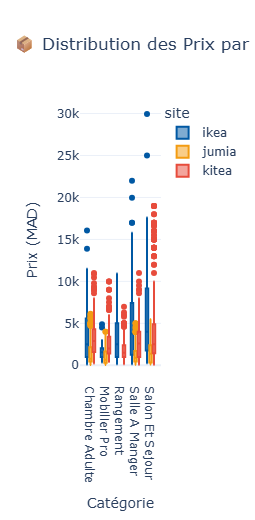

✅ fig_boxplot.json sauvegardé


In [31]:
fig_box = px.box(df_clean, x='categorie', y='prix', color='site',
    color_discrete_map=COLORS,
    title='📦 Distribution des Prix par Catégorie et Site (MAD)',
    labels={'prix':'Prix (MAD)','categorie':'Catégorie'},
    template='plotly_white')
fig_box.update_layout(height=520)
fig_box.show()
with open('../outputs/fig_boxplot.json','w') as f: f.write(fig_box.to_json())
print("✅ fig_boxplot.json sauvegardé")

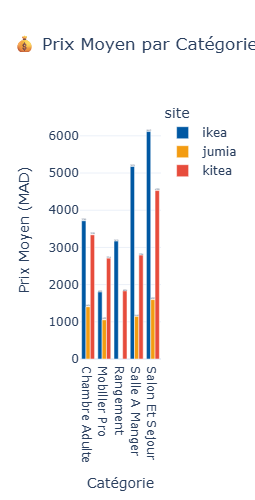

✅ fig_barchart.json sauvegardé


In [32]:
prix_moy = df_clean.groupby(['categorie','site'])['prix'].mean().round(0).reset_index()
fig_bar = px.bar(prix_moy, x='categorie', y='prix', color='site', barmode='group',
    color_discrete_map=COLORS,
    title='💰 Prix Moyen par Catégorie et Site (MAD)',
    labels={'prix':'Prix Moyen (MAD)','categorie':'Catégorie'},
    template='plotly_white', text='prix')
fig_bar.update_traces(texttemplate='%{text:.0f}', textposition='outside')
fig_bar.update_layout(height=500)
fig_bar.show()
with open('../outputs/fig_barchart.json','w') as f: f.write(fig_bar.to_json())
print("✅ fig_barchart.json sauvegardé")

## 🔬 Étape 4 — Tests statistiques

In [33]:
# Shapiro-Wilk
shapiro_results = {}
print("=== SHAPIRO-WILK ===")
for site in df_clean['site'].unique():
    s = df_clean[df_clean['site']==site]['prix'].dropna().sample(
        min(5000,len(df_clean[df_clean['site']==site])),random_state=42)
    stat, p = shapiro(s)
    shapiro_results[site] = {'stat':round(float(stat),4),'p_value':round(float(p),6),'normal':bool(p>0.05)}
    print(f"  {site:8}: stat={stat:.4f}, p={p:.6f} → Normal: {p>0.05}")

# Kruskal-Wallis
groups_cat  = [df_clean[df_clean['categorie']==c]['prix'].dropna().values for c in df_clean['categorie'].unique()]
groups_site = [df_clean[df_clean['site']==s]['prix'].dropna().values      for s in df_clean['site'].unique()]
stat_kc,p_kc = kruskal(*groups_cat)
stat_ks,p_ks = kruskal(*groups_site)
kruskal_cat  = {'stat':round(float(stat_kc),4),'p_value':round(float(p_kc),6)}
kruskal_site = {'stat':round(float(stat_ks),4),'p_value':round(float(p_ks),6)}
print(f"\nKruskal Catégories : stat={stat_kc:.4f}, p={p_kc:.2e} → {p_kc<0.05}")
print(f"Kruskal Sites      : stat={stat_ks:.4f}, p={p_ks:.2e} → {p_ks<0.05}")

=== SHAPIRO-WILK ===
  ikea    : stat=0.7952, p=0.000000 → Normal: False
  jumia   : stat=0.8505, p=0.000000 → Normal: False
  kitea   : stat=0.7131, p=0.000000 → Normal: False

Kruskal Catégories : stat=55.3807, p=2.70e-11 → True
Kruskal Sites      : stat=515.0679, p=1.43e-112 → True


In [34]:
# Mann-Whitney : comparaison paires de sites par catégorie
mw_results = {}
sites = list(df_clean['site'].unique())
print("=== MANN-WHITNEY U ===")
for cat in df_clean['categorie'].unique():
    mw_results[cat] = {}
    print(f"\n{cat}:")
    for s1,s2 in [(sites[0],sites[1]),(sites[0],sites[2]),(sites[1],sites[2])]:
        g1 = df_clean[(df_clean['site']==s1)&(df_clean['categorie']==cat)]['prix'].dropna()
        g2 = df_clean[(df_clean['site']==s2)&(df_clean['categorie']==cat)]['prix'].dropna()
        if len(g1)>5 and len(g2)>5:
            stat,p = mannwhitneyu(g1,g2,alternative='two-sided')
            plus_cher = s1 if g1.median()>g2.median() else s2
            mw_results[cat][f'{s1}_vs_{s2}'] = {
                'stat':round(float(stat),2),'p_value':round(float(p),6),
                'significatif':bool(p<0.05),
                f'median_{s1}':round(float(g1.median()),2),
                f'median_{s2}':round(float(g2.median()),2),
                'plus_cher':plus_cher}
            sig = "✅" if p<0.05 else "❌"
            print(f"  {s1} vs {s2}: {g1.median():.0f} vs {g2.median():.0f} MAD {sig} (p={p:.4f}) — Plus cher: {plus_cher}")

=== MANN-WHITNEY U ===

Chambre Adulte:
  ikea vs jumia: 2495 vs 790 MAD ✅ (p=0.0000) — Plus cher: ikea
  ikea vs kitea: 2495 vs 2895 MAD ❌ (p=0.5955) — Plus cher: kitea
  jumia vs kitea: 790 vs 2895 MAD ✅ (p=0.0000) — Plus cher: kitea

Mobilier Pro:
  ikea vs jumia: 1538 vs 660 MAD ✅ (p=0.0007) — Plus cher: ikea
  ikea vs kitea: 1538 vs 1999 MAD ✅ (p=0.0158) — Plus cher: kitea
  jumia vs kitea: 660 vs 1999 MAD ✅ (p=0.0000) — Plus cher: kitea

Rangement:
  ikea vs kitea: 2500 vs 1495 MAD ✅ (p=0.0013) — Plus cher: ikea

Salle A Manger:
  ikea vs jumia: 3799 vs 897 MAD ✅ (p=0.0000) — Plus cher: ikea
  ikea vs kitea: 3799 vs 2595 MAD ✅ (p=0.0005) — Plus cher: ikea
  jumia vs kitea: 897 vs 2595 MAD ✅ (p=0.0000) — Plus cher: kitea

Salon Et Sejour:
  ikea vs jumia: 3999 vs 1379 MAD ✅ (p=0.0000) — Plus cher: ikea
  ikea vs kitea: 3999 vs 2495 MAD ✅ (p=0.0426) — Plus cher: ikea
  jumia vs kitea: 1379 vs 2495 MAD ✅ (p=0.0000) — Plus cher: kitea


In [35]:
# Régression linéaire
df_reg = df_clean.copy()
df_reg['en_promo_num'] = df_reg['en_promotion'].astype(int)
model = smf.ols('prix ~ C(site) + C(categorie) + en_promo_num',
    data=df_reg.dropna(subset=['prix','categorie','site'])).fit()
reg_results = {
    'r2':round(float(model.rsquared),4),
    'r2_adj':round(float(model.rsquared_adj),4),
    'f_stat':round(float(model.fvalue),2),
    'p_global':round(float(model.f_pvalue),6),
    'coefficients':{k:round(float(v),2) for k,v in model.params.items()},
    'p_values':{k:round(float(v),4) for k,v in model.pvalues.items()}
}
print(f"R² ajusté : {reg_results['r2_adj']} ({reg_results['r2_adj']*100:.1f}% variance expliquée)")
print(f"F-stat    : {reg_results['f_stat']}, p={reg_results['p_global']}")
print("\nCoefficients significatifs (p<0.05):")
for k,p in reg_results['p_values'].items():
    if p<0.05: print(f"  {k}: {reg_results['coefficients'][k]:+.0f} MAD (p={p:.4f})")

R² ajusté : 0.1891 (18.9% variance expliquée)
F-stat    : 89.15, p=0.0

Coefficients significatifs (p<0.05):
  Intercept: +4363 MAD (p=0.0000)
  C(site)[T.jumia]: -2799 MAD (p=0.0000)
  C(site)[T.kitea]: -870 MAD (p=0.0000)
  C(categorie)[T.Mobilier Pro]: -484 MAD (p=0.0039)
  C(categorie)[T.Rangement]: -1429 MAD (p=0.0000)
  C(categorie)[T.Salon Et Sejour]: +1028 MAD (p=0.0000)
  en_promo_num: -456 MAD (p=0.0001)


## 📈 Étape 5 — Évolution des Prix (Bigtable-ready)
> En production : `df_hist = lecture_bigtable(start_date, end_date)` → même code ensuite

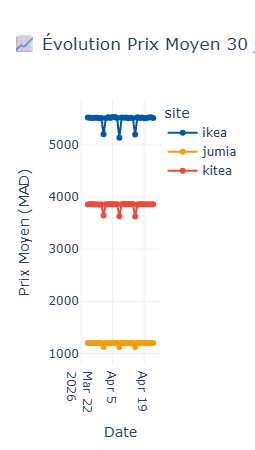

✅ fig_evolution.json sauvegardé


In [36]:
df_hist = pd.read_csv('../data/raw/historique_prices.csv', parse_dates=['date_scraping'])
evol = df_hist.groupby(['site','date_scraping'])['prix'].mean().round(2).reset_index()

fig_evol = px.line(evol, x='date_scraping', y='prix', color='site',
    color_discrete_map=COLORS,
    title='📈 Évolution Prix Moyen 30 jours — Kitea vs Jumia vs Ikea',
    labels={'prix':'Prix Moyen (MAD)','date_scraping':'Date'},
    template='plotly_white', markers=True)
fig_evol.update_layout(height=450)
fig_evol.show()
with open('../outputs/fig_evolution.json','w') as f: f.write(fig_evol.to_json())
print("✅ fig_evolution.json sauvegardé")

In [37]:
# Anomalies (variation > 20%)
anomalies_list = []
for (pid,site), grp in df_hist.groupby(['product_id','site']):
    if len(grp) < 5: continue
    prix_s = grp.sort_values('date_scraping')['prix']
    var = prix_s.pct_change().abs()
    if (var > 0.20).any():
        row_p = df_clean[df_clean['product_id']==pid]
        if len(row_p):
            anomalies_list.append({
                'product_id':pid,'nom':str(row_p.iloc[0]['nom'])[:50],
                'site':site,'categorie':str(row_p.iloc[0]['categorie']),
                'variation_max_pct':round(float(var.max())*100,1)})
print(f"Anomalies détectées : {len(anomalies_list)}")
if anomalies_list:
    display(pd.DataFrame(anomalies_list).head(10))

Anomalies détectées : 1283


,product_id,nom,site,categorie,variation_max_pct
0,IKE-0000,KIVIK,ikea,Salon Et Sejour,27.1
1,IKE-0001,ROCKSJÖN,ikea,Salon Et Sejour,32.8
2,IKE-0002,EKTORP,ikea,Salon Et Sejour,29.6
3,IKE-0003,SALTSJÖBADEN,ikea,Salon Et Sejour,28.0
4,IKE-0004,LANDSKRONA,ikea,Salon Et Sejour,24.5
5,IKE-0005,SLATORP,ikea,Salon Et Sejour,28.7
6,IKE-0008,HYLTARP,ikea,Salon Et Sejour,26.8
7,IKE-0011,ÄPPLARYD,ikea,Salon Et Sejour,25.7
8,IKE-0012,EKHOLMA,ikea,Salon Et Sejour,22.0
9,IKE-0017,SÖDERHAMN,ikea,Salon Et Sejour,34.3


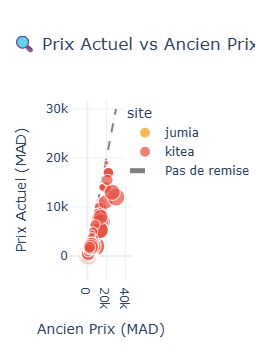

✅ fig_scatter.json sauvegardé


In [38]:
# Scatter Prix actuel vs Ancien prix
df_sc = df_clean[df_clean['ancien_prix'].notna()].copy()
if len(df_sc) > 0:
    fig_sc = px.scatter(df_sc, x='ancien_prix', y='prix', color='site',
        size='remise_pct', hover_data=['nom','categorie','remise_pct'],
        color_discrete_map=COLORS,
        title='🔍 Prix Actuel vs Ancien Prix — Taille bulle = Remise %',
        labels={'ancien_prix':'Ancien Prix (MAD)','prix':'Prix Actuel (MAD)'},
        template='plotly_white')
    max_p = df_sc['ancien_prix'].max()
    fig_sc.add_trace(go.Scatter(x=[0,max_p],y=[0,max_p],mode='lines',
        name='Pas de remise',line=dict(dash='dash',color='gray')))
    fig_sc.show()
    with open('../outputs/fig_scatter.json','w') as f: f.write(fig_sc.to_json())
    print("✅ fig_scatter.json sauvegardé")
else:
    print("ℹ️ Pas de données avec ancien_prix pour Ikea")

## 💾 Étape 6 — Export JSON pour le Fullstack
> L'API FastAPI (`api/main.py`) lit `analyse_results.json` et expose les données via HTTP

In [39]:
# Vérification
print("=== VÉRIFICATION VARIABLES ===")
for v in ['stats_site','stats_cat','promo_stats','shapiro_results',
          'kruskal_cat','kruskal_site','mw_results','reg_results','anomalies_list','evol']:
    print(f"  {'✅' if v in dir() else '❌'} {v}")

=== VÉRIFICATION VARIABLES ===
  ✅ stats_site
  ✅ stats_cat
  ✅ promo_stats
  ✅ shapiro_results
  ✅ kruskal_cat
  ✅ kruskal_site
  ✅ mw_results
  ✅ reg_results
  ✅ anomalies_list
  ✅ evol


In [40]:
evol_exp = evol.copy()
evol_exp['date_scraping'] = evol_exp['date_scraping'].astype(str)

final_results = {
    'meta': {
        'date_analyse'       : pd.Timestamp.now().strftime('%Y-%m-%d %H:%M'),
        'nb_produits'        : int(len(df_clean)),
        'nb_categories'      : int(df_clean['categorie'].nunique()),
        'sites'              : list(df_clean['site'].unique()),
        'periode_historique' : '30 jours',
        'note_production'    : 'Source: Google Cloud Bigtable — mise à jour quotidienne',
    },
    'stats_par_site'      : json.loads(stats_site.to_json()),
    'stats_par_categorie' : json.loads(stats_cat.to_json()),
    'promotions'          : json.loads(promo_stats.to_json()),
    'shapiro'             : shapiro_results,
    'kruskal_categories'  : kruskal_cat,
    'kruskal_sites'       : kruskal_site,
    'mann_whitney'        : mw_results,
    'regression'          : reg_results,
    'evolution_prix'      : evol_exp.to_dict(orient='records'),
    'anomalies'           : anomalies_list[:50],
}

with open('../outputs/analyse_results.json','w',encoding='utf-8') as f:
    json.dump(final_results, f, ensure_ascii=False, indent=2, default=str)

print("✅ EXPORT COMPLET !")
print("  ├─ outputs/analyse_results.json")
print("  ├─ outputs/fig_boxplot.json")
print("  ├─ outputs/fig_barchart.json")
print("  ├─ outputs/fig_evolution.json")
print("  └─ outputs/fig_scatter.json")
print()
print("--- RÉSUMÉ FINAL ---")
print(f"Produits analysés   : {len(df_clean):,}")
print(f"Sites               : Kitea · Jumia · Ikea")
print(f"Catégories          : {df_clean['categorie'].nunique()}")
print(f"En promotion        : {df_clean['en_promotion'].sum():,} ({df_clean['en_promotion'].mean()*100:.1f}%)")
print(f"R² régression       : {reg_results['r2_adj']}")
print(f"Anomalies détectées : {len(anomalies_list)}")
print()
print("✅ Prêt à livrer au Fullstack via API FastAPI !")

✅ EXPORT COMPLET !
  ├─ outputs/analyse_results.json
  ├─ outputs/fig_boxplot.json
  ├─ outputs/fig_barchart.json
  ├─ outputs/fig_evolution.json
  └─ outputs/fig_scatter.json

--- RÉSUMÉ FINAL ---
Produits analysés   : 2,647
Sites               : Kitea · Jumia · Ikea
Catégories          : 5
En promotion        : 1,456 (55.0%)
R² régression       : 0.1891
Anomalies détectées : 1283

✅ Prêt à livrer au Fullstack via API FastAPI !
